# Load Data
## Condition
* normal (original SSVEP keyboard forked from [Simon's Repo](https://github.com/simonfei123/OpenVEP))
* red-green
* blue-yellow

## Data collection
* Did 5 runs for each condition
* Keyboard: 32 keys, Number of classes
* Trials per class: 2, Each key stimulus presented twice
* Channel: Number of EEG channel
* Sample: 350, (baseline_duration 0.2 + stimulus_duration 1.2) * sampling_rate 250

### 1: Imports

In [1]:
# 1: Import 

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2: Basic experiment settings

In [2]:
# Paths
CONDITION_DIRS = {
    "normal": Path("../data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02"),
    "red_green": Path("../data/redgreen_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01"),
    "blue_yellow": Path("../data/blueyellow_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01"),
}

OUTPUT_DIR = Path("../derived")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Experiment constants
FS = 250
N_CLASSES = 32
N_REPEATS = 2
N_CHANNELS = 8
N_SAMPLES = 350

BASELINE_SEC = 0.2
STIM_SEC = 1.2
BASELINE_SAMPLES = int(BASELINE_SEC * FS)   # 50
STIM_SAMPLES = int(STIM_SEC * FS)           # 300

EXPECTED_TRIALS = N_CLASSES * N_REPEATS     # 64

CHANNEL_NAMES = [f"Ch{i+1}" for i in range(N_CHANNELS)]

sns.set_theme(style="whitegrid")

### Helper Function

In [3]:
def extract_run_number(path: Path):
    match = re.search(r"run-(\d+)", path.name)
    return int(match.group(1)) if match else None


def find_eeg_trial_files(condition_dir: Path):
    files = sorted(condition_dir.glob("eeg-trials_2-per-class_run-*.npy"))
    return sorted(files, key=extract_run_number)


def build_trial_order_from_run(run_number, n_classes=32, n_repeats=2):
    rng = np.random.RandomState(run_number)
    target_by_trial = np.tile(np.arange(n_classes), (n_repeats, 1))
    for repeat_idx in range(n_repeats):
        rng.shuffle(target_by_trial[repeat_idx])
    return target_by_trial.reshape(-1)


def reshape_trials_by_repeat_and_class(eeg_flat, target_by_trial_flat, n_classes=32, n_repeats=2):
    eeg_reshaped = np.empty((n_repeats, n_classes, eeg_flat.shape[1], eeg_flat.shape[2]), dtype=eeg_flat.dtype)
    repeat_counts = np.zeros(n_classes, dtype=int)

    for trial_idx, class_id in enumerate(target_by_trial_flat):
        rep = repeat_counts[class_id]
        eeg_reshaped[rep, class_id] = eeg_flat[trial_idx]
        repeat_counts[class_id] += 1

    return eeg_reshaped

In [4]:
# Check files
for condition_name, condition_dir in CONDITION_DIRS.items():
    eeg_files = find_eeg_trial_files(condition_dir)
    print(f"{condition_name}: {[f.name for f in eeg_files]}")

normal: ['eeg-trials_2-per-class_run-1.npy', 'eeg-trials_2-per-class_run-2.npy', 'eeg-trials_2-per-class_run-3.npy', 'eeg-trials_2-per-class_run-4.npy', 'eeg-trials_2-per-class_run-5.npy']
red_green: ['eeg-trials_2-per-class_run-1.npy', 'eeg-trials_2-per-class_run-2.npy', 'eeg-trials_2-per-class_run-3.npy', 'eeg-trials_2-per-class_run-4.npy', 'eeg-trials_2-per-class_run-5.npy']
blue_yellow: ['eeg-trials_2-per-class_run-1.npy', 'eeg-trials_2-per-class_run-2.npy', 'eeg-trials_2-per-class_run-3.npy', 'eeg-trials_2-per-class_run-4.npy', 'eeg-trials_2-per-class_run-5.npy']


### 3: Load all runs for each condition
* Read files
* Return shuffled trial order to original
* Pick up stimulus part and save

In [5]:
trial_metadata_rows = []
all_trials_stim_list = []

global_trial_index = 0

for condition_name, condition_dir in CONDITION_DIRS.items():
    eeg_files = find_eeg_trial_files(condition_dir)

    for eeg_file in eeg_files:
        run_number = extract_run_number(eeg_file)
        eeg_flat = np.load(eeg_file)  # expected shape: (64, 8, 350)

        assert eeg_flat.shape == (EXPECTED_TRIALS, N_CHANNELS, N_SAMPLES), \
            f"Unexpected shape in {eeg_file.name}: {eeg_flat.shape}"

        target_by_trial_flat = build_trial_order_from_run(
            run_number=run_number,
            n_classes=N_CLASSES,
            n_repeats=N_REPEATS
        )

        eeg_reshaped = reshape_trials_by_repeat_and_class(
            eeg_flat=eeg_flat,
            target_by_trial_flat=target_by_trial_flat,
            n_classes=N_CLASSES,
            n_repeats=N_REPEATS
        )

        for repeat_idx in range(N_REPEATS):
            for class_id in range(N_CLASSES):
                x_full = eeg_reshaped[repeat_idx, class_id]         # (8, 350)
                x_stim = x_full[:, BASELINE_SAMPLES:]               # (8, 300)

                trial_metadata_rows.append({
                    "participant": 1,
                    "condition": condition_name,
                    "run": run_number,
                    "trial_repeat": repeat_idx,
                    "class_id": class_id,
                    "true_label": class_id,
                    "global_trial_index": global_trial_index,
                })

                all_trials_stim_list.append(x_stim)
                global_trial_index += 1

### Convert to filan objects

In [6]:
trial_metadata = pd.DataFrame(trial_metadata_rows).sort_values(
    by=["condition", "run", "trial_repeat", "class_id"]
).reset_index(drop=True)

all_trials_stim = np.stack(all_trials_stim_list, axis=0)

print("trial_metadata shape:", trial_metadata.shape)
print("all_trials_stim shape:", all_trials_stim.shape)

trial_metadata.head()

trial_metadata shape: (960, 7)
all_trials_stim shape: (960, 8, 300)


,participant,condition,run,trial_repeat,class_id,true_label,global_trial_index
0,1,blue_yellow,1,0,0,0,640
1,1,blue_yellow,1,0,1,1,641
2,1,blue_yellow,1,0,2,2,642
3,1,blue_yellow,1,0,3,3,643
4,1,blue_yellow,1,0,4,4,644


### Quality Check
* check if any missing data

In [7]:
print("Any NaN in all_trials_stim:", np.isnan(all_trials_stim).any())
print("Any inf in all_trials_stim:", np.isinf(all_trials_stim).any())

trial_counts = (
    trial_metadata
    .groupby(["condition", "run"])
    .size()
    .reset_index(name="n_trials")
)

trial_counts

Any NaN in all_trials_stim: False
Any inf in all_trials_stim: False


,condition,run,n_trials
0,blue_yellow,1,64
1,blue_yellow,2,64
2,blue_yellow,3,64
3,blue_yellow,4,64
4,blue_yellow,5,64
5,normal,1,64
6,normal,2,64
7,normal,3,64
8,normal,4,64
9,normal,5,64


### (Quick waveform check)

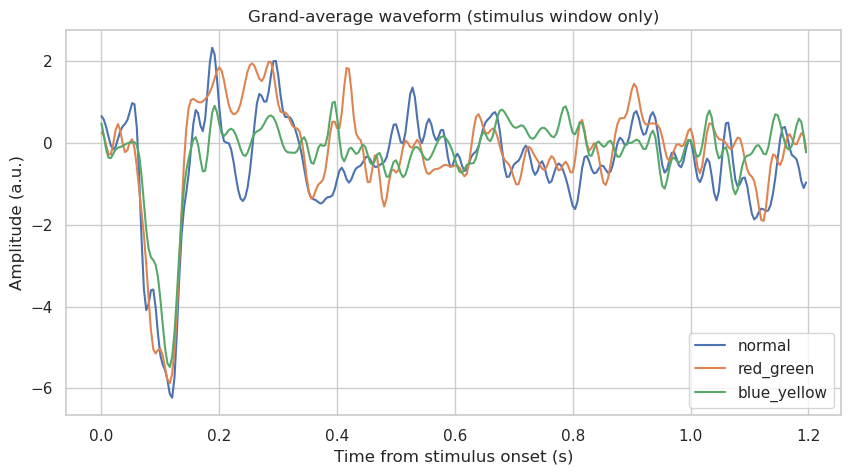

In [8]:
time_stim = np.arange(all_trials_stim.shape[-1]) / FS

plt.figure(figsize=(10, 5))

for condition_name in CONDITION_DIRS.keys():
    mask = trial_metadata["condition"] == condition_name
    x = all_trials_stim[mask.values]          # (n_trials, 8, 300)
    grand_avg = x.mean(axis=(0, 1))           # average over trials and channels
    plt.plot(time_stim, grand_avg, label=condition_name)

plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Grand-average waveform (stimulus window only)")
plt.legend()
plt.show()

### Save outputs

In [9]:
trial_metadata.to_csv(OUTPUT_DIR / "trial_metadata.csv", index=False)
np.save(OUTPUT_DIR / "all_trials_stim.npy", all_trials_stim)

print("Saved:")
print(OUTPUT_DIR / "trial_metadata.csv")
print(OUTPUT_DIR / "all_trials_stim.npy")

Saved:
../derived/trial_metadata.csv
../derived/all_trials_stim.npy
